In [1]:
# # Deterministic cat-state generation

# [H. Ritsch, et al., Phys. Rev. A 70, 033804 (2004)](https://doi.org/10.1103%2FPhysRevA.70.033804)
# As usual, we start by loading the packages and specifying the system. 

using QuantumInputOutput
using SecondQuantizedAlgebra
using QuantumOptics
using QuantumCumulants
using LinearAlgebra
using PyPlot

Precompiling DiffEqBaseChainRulesCoreExt
        Info Given DiffEqBaseChainRulesCoreExt was explicitly requested, output will be shown live 
ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.
  ? DiffEqBase → DiffEqBaseChainRulesCoreExt
[ Info: Precompiling DiffEqBaseChainRulesCoreExt [b00db79b-61e3-50fb-b26f-2d35b2d9e4ed]
ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.
[ Info: Skipping precompilation since __precompile__(false). Importing DiffEqBaseChainRulesCoreExt [b00db79b-61e3-50fb-b26f-2d35b2d9e4ed].


In [2]:
@rnumbers κ g γ Δa Δc
@cnumbers η gv
Natoms = 1

hc = FockSpace(:cavity)
ha = NLevelSpace(:atom, 2)
hv = FockSpace(:output)
h = hc ⊗ ha ⊗ hv


ℋ(cavity) ⊗ ℋ(atom) ⊗ ℋ(output)

In [3]:
a = Destroy(h, :a, 1) # cavity 
σ(i, j) = Transition(h, "σ", i, j, 2) # two-level atom
av = Destroy(h, :a_v, 3) # output cavity
nothing # hide 

# We couple a classical drive into the cavity through the left mirror $(\kappa_L)$. The decay through the right mirror can be added in several ways: with the `concatenate` rule, including it already in the initial cavity SLH triple or by simply including the decay term to the Lindblad by hand. In this example, we use the first option. 

In [4]:
H_ac = -Δc*a'a - Δa*σ(2, 2) - g*(σ(2, 1)*a + σ(1, 2)*a') + η*σ(2, 1) + η'*σ(1, 2)
J = [√(κ)*a, √(γ)*σ(1, 2)]


2-element Vector{SecondQuantizedAlgebra.QMul{Nothing}}:
 sqrt(κ)*(a)
 sqrt(γ)*(σ12)

In [5]:
## numerical parameters
κ_ = 8.0 # 1.0
γ_ = 0.25
g_ = 50.0
Δa_ = 0.0
Δc_ = 0.0

p_sym = [κ,  γ, Δa, Δc]
p_num = [κ_, γ_, Δa_, Δc_]
dict_p = Dict(p_sym .=> p_num)

Dict{SymbolicUtils.BasicSymbolic{Real}, Float64} with 4 entries:
  γ  => 0.25
  κ  => 8.0
  Δc => 0.0
  Δa => 0.0

In [6]:
# Gaussian pulse (definiton?)
η0 =  20g_# 9g_
τ  = 0.1/κ_
Tend = 40τ

η_t(t) = η0*exp(-(t-4*τ)^2 / (1.1*τ^2))

η_t (generic function with 1 method)

In [7]:
### rectangular pulse
# η0 = √(8)*g_

T_pulse = 2π*τ 
g_t(t) = (t<T_pulse)*√2*g_ 

ηc_t(t) = conj(η_t(t))
gc_t(t) = conj(g_t(t))

dict_t = Dict([η, conj(η), g, conj(g)] .=> [η_t, ηc_t,g_t,gc_t])
T = [0:0.00125:1;]*Tend
ΔT = T[2] - T[1]


0.000625

In [8]:
g_*T_pulse

3.9269908169872414

In [9]:
## numerical basis
bc = FockBasis(16)
ba = NLevelBasis(2)
bv = FockBasis(16)
b = bc ⊗ ba ⊗ bv
#
a_QO = destroy(bc) ⊗ one(ba)
ad_QO = dagger(a_QO)
σ_QO(i, j) = one(bc) ⊗ transition(ba, i, j)

σ_QO (generic function with 1 method)

In [10]:
ops_sym = [a, a', σ(2, 2), σ(1, 2), σ(2, 1)]
ops_QO = [a_QO, dagger(a_QO), σ_QO(2, 2), σ_QO(1, 2), σ_QO(2, 1)]
ops_dict = Dict(ops_sym .=> ops_QO);

In [11]:
H_QO =
    translate_qo(H_ac, b; parameter = dict_p, time_parameter = dict_t, operators = ops_dict)
L_QO = translate_qo(√(κ)*a, b; parameter = dict_p, operators = ops_dict)
J_add_QO = √(γ_)*σ_QO(1, 2)

J = [L_QO, J_add_QO]
Jd = dagger.(J);


In [12]:
function input_output(t, ρ)
    H = H_QO(t)
    return H, J, Jd
end


input_output (generic function with 1 method)

In [13]:
ψ0 = fockstate(bc, 0) ⊗ nlevelstate(ba, 1)
t_, ρt = timeevolution.master_dynamic(T, ψ0, input_output)

n_t = real(expect(ad_QO*a_QO, ρt))
σ22_t = real(expect(σ_QO(2, 2), ρt))
tr_ρa2 = tr.(ptrace.(ρt, 1) .^ 2); 

In [14]:
n_out = sum(n_t)*κ_*ΔT
@show n_out

n_out = 2.3788009613175034


2.3788009613175034

/usr/lib/python3/dist-packages/numpy/core/_asarray.py:85: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


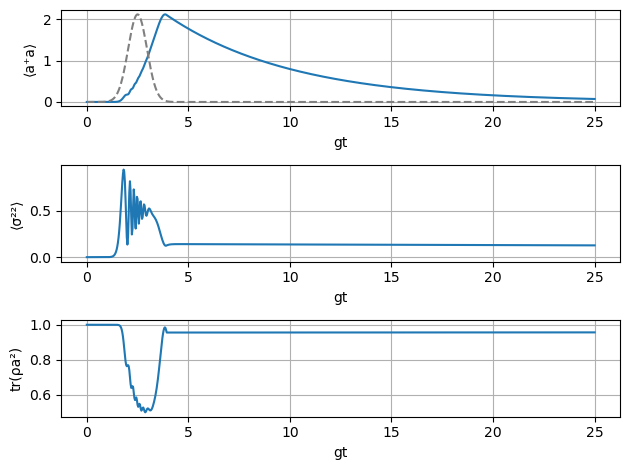

In [15]:
close("n(t)")
figure("n(t)")
subplot(311)
plot(t_*g_, n_t)
plot(T*g_, η_t.(T)/η0*maximum(n_t), ls = "--", color = "grey")
grid(true)
xlabel("gt")
ylabel("⟨a⁺a⟩")
subplot(312)
plot(t_*g_, σ22_t)
grid(true)
xlabel("gt")
ylabel("⟨σ²²⟩")
subplot(313)
plot(t_*g_, tr_ρa2)
grid(true)
xlabel("gt")
ylabel("tr(ρa²)")
tight_layout()

single_mode = 0.9974739077050487


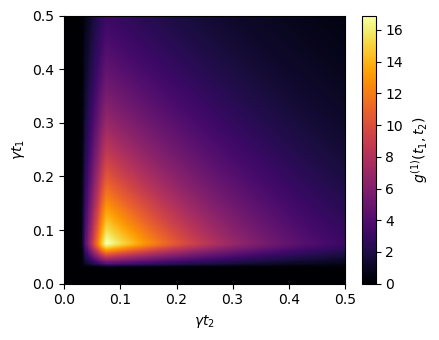

0.9974739077050487

In [16]:
Ls(t) = L_QO
g1_m = two_time_corr_matrix(T, ρt, input_output, Ls) # TODO: two_time_corr_matrix for Ls = const

close("g1(t1,t2) matrix") # hide
figure("g1(t1,t2) matrix", figsize = (4.5, 3.5))
pcolormesh(T, T, real.(g1_m), cmap = "inferno")
xlabel(L"\gamma t_2")
ylabel(L"\gamma t_1")
colorbar(label = L"g^{(1)}(t_1,t_2)")
tight_layout()

F = eigen(g1_m)
n_avg = real.(F.values)*ΔT
modes = F.vectors
v1_mode = (modes[:, end]) / √(ΔT)

single_mode = n_avg[end]/n_out
@show single_mode


In [17]:
# time-dependent coupling for the output mode $v(t)$
gv_t = v_to_gv(v1_mode, T)
gvc_t = t -> conj(gv_t(t))
dict_t_2 = Dict([η, conj(η), gv, conj(gv),  g, conj(g)] .=> 
    [η_t, ηc_t, gv_t, gvc_t, g_t, gc_t])


Dict{SymbolicUtils.BasicSymbolic, Function} with 5 entries:
  g        => gc_t
  η        => η_t
  gv       => #83
  conj(η)  => ηc_t
  conj(gv) => #1

In [18]:
# needed later # TODO: move down
G_ac = SLH(1, [√(κ)*a], H_ac)
G_v = SLH(1, [gv*av], 0)
G_cas = G_ac ▷ G_v

H_2 = G_cas.hamiltonian
L_2 = G_cas.lindblad[1]

H_QO_2 = translate_qo(H_2, b; parameter = dict_p, time_parameter = dict_t_2)
L_QO_2 = translate_qo(L_2, b; parameter = dict_p, time_parameter = dict_t_2)
J_add_QO_2 = translate_qo(√(γ)*σ(1, 2), b; parameter = dict_p)


Operator(dim=578x578)
  basis: [Fock(cutoff=16) ⊗ NLevel(N=2) ⊗ Fock(cutoff=16)]sparse([1, 2, 3, 4, 5, 6, 7, 8, 9, 10  …  552, 553, 554, 555, 556, 557, 558, 559, 560, 561], [18, 19, 20, 21, 22, 23, 24, 25, 26, 27  …  569, 570, 571, 572, 573, 574, 575, 576, 577, 578], ComplexF64[0.5 + 0.0im, 0.5 + 0.0im, 0.5 + 0.0im, 0.5 + 0.0im, 0.5 + 0.0im, 0.5 + 0.0im, 0.5 + 0.0im, 0.5 + 0.0im, 0.5 + 0.0im, 0.5 + 0.0im  …  0.5 + 0.0im, 0.5 + 0.0im, 0.5 + 0.0im, 0.5 + 0.0im, 0.5 + 0.0im, 0.5 + 0.0im, 0.5 + 0.0im, 0.5 + 0.0im, 0.5 + 0.0im, 0.5 + 0.0im], 578, 578)

In [19]:
function input_output_2(t, ρ)
    H = H_QO_2(t)
    J = [L_QO_2(t); J_add_QO_2]
    return H, J, dagger.(J)
end


input_output_2 (generic function with 1 method)

In [20]:
ψ0_2 = ψ0 ⊗ fockstate(bv, 0)
t_2, ρt_2 = timeevolution.master_dynamic(T, ψ0_2, input_output_2)

av_QO_2 = translate_qo(av, b)
n_v1_t = real(expect(dagger(av_QO_2)*av_QO_2, ρt_2))
n_v1_t[end]

ρ_end_output = ptrace(ρt_2[end], [1, 2])

tr(ρ_end_output^2)

0.845575991174775 + 0.0im

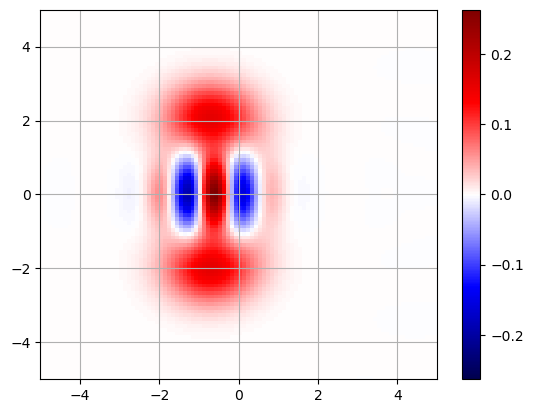

PyObject <matplotlib.colorbar.Colorbar object at 0x7ff072cf1100>

In [21]:
### wigner function 
x_ls = [-5:0.1:5;]
wig = wigner(ρ_end_output, x_ls, x_ls)

close("wigner")
figure("wigner")
v = maximum(real(wig))
pcolormesh(x_ls, x_ls, transpose(real(wig)), cmap = "seismic", vmin = -v, vmax = v)
grid(true)
colorbar()
